# PDF-to-1NF Pipeline Demo

Interactive demonstration of the complete OCR and table normalization pipeline.

**Pipeline:**
1. PDF → Images (Poppler)
2. Images → Markdown Tables (Tesseract OCR + Spatial Extraction)
3. Heal Markdown (Fix merged cells using inferred schema)
4. Extract → 1NF Structured Data (BAML AI with user schema)

## Setup Validation

Let's verify your environment is ready.

In [1]:
# Cell 1: Check Python dependencies
import sys
from pathlib import Path

print("🔍 Checking Python dependencies...\n")

required_packages = [
    ('numpy', 'numpy'),
    ('cv2', 'opencv-python'),
    ('pdf2image', 'pdf2image'),
    ('PIL', 'pillow'),
    ('pytesseract', 'pytesseract'),
    ('baml_py', 'baml-py'),
    ('pydantic', 'pydantic'),
]

missing = []
for module, package in required_packages:
    try:
        __import__(module)
        print(f"✅ {package}")
    except ImportError:
        print(f"❌ {package} - NOT FOUND")
        missing.append(package)

if missing:
    print(f"\n⚠️  Missing packages: {', '.join(missing)}")
    print("\nRun: uv sync")
else:
    print("\n✅ All Python dependencies installed!")

🔍 Checking Python dependencies...

✅ numpy
✅ opencv-python
✅ pdf2image
✅ pillow
✅ pytesseract
✅ baml-py
✅ pydantic

✅ All Python dependencies installed!


In [2]:
# Cell 2: Check system dependencies
import subprocess
import shutil

print("🔍 Checking system dependencies...\n")

# Check Tesseract
tesseract_path = shutil.which('tesseract')
if tesseract_path:
    result = subprocess.run(['tesseract', '--version'], capture_output=True, text=True)
    version = result.stdout.split('\n')[0]
    print(f"✅ Tesseract OCR: {version}")
    print(f"   Location: {tesseract_path}")
else:
    print("❌ Tesseract OCR - NOT FOUND")
    print("   Install: brew install tesseract (macOS) or apt-get install tesseract-ocr (Linux)")

# Check Poppler (for pdf2image)
pdfinfo_path = shutil.which('pdfinfo')
if pdfinfo_path:
    result = subprocess.run(['pdfinfo', '-v'], capture_output=True, text=True)
    version = result.stderr.split('\n')[0] if result.stderr else 'installed'
    print(f"\n✅ Poppler: {version}")
    print(f"   Location: {pdfinfo_path}")
else:
    print("\n❌ Poppler - NOT FOUND")
    print("   Install: brew install poppler (macOS) or apt-get install poppler-utils (Linux)")

print("\n" + "="*60)

🔍 Checking system dependencies...

✅ Tesseract OCR: tesseract 5.5.1
   Location: /opt/homebrew/bin/tesseract

✅ Poppler: pdfinfo version 25.09.1
   Location: /opt/homebrew/bin/pdfinfo



In [3]:
# Cell 3: Check API keys for BAML
import os

print("🔍 Checking API keys for BAML...\n")

api_keys = {
    'ANTHROPIC_API_KEY': 'Anthropic (Claude)',
    'OPENAI_API_KEY': 'OpenAI (GPT)',
}

found_keys = []
for key, name in api_keys.items():
    if os.getenv(key):
        masked = os.getenv(key)[:8] + '...' + os.getenv(key)[-4:]
        print(f"✅ {name}: {masked}")
        found_keys.append(name)
    else:
        print(f"❌ {name}: Not set")

if found_keys:
    print(f"\n✅ BAML ready with: {', '.join(found_keys)}")
else:
    print("\n⚠️  No API keys found. BAML normalization won't work.")
    print("\nSet one of these environment variables:")
    print("  export ANTHROPIC_API_KEY=your_key")
    print("  export OPENAI_API_KEY=your_key")

print("\n" + "="*60)

🔍 Checking API keys for BAML...

❌ Anthropic (Claude): Not set
✅ OpenAI (GPT): sk-proj-...h_UA

✅ BAML ready with: OpenAI (GPT)



In [4]:
# Cell 4: Import our modules
print("📦 Loading pipeline modules...\n")

try:
    from pdf_to_markdown import pdf_to_markdown
    print("✅ pdf_to_markdown")
except ImportError as e:
    print(f"❌ pdf_to_markdown: {e}")

try:
    from table_normalizer import process_ocr_table, save_normalized_data
    print("✅ table_normalizer")
except ImportError as e:
    print(f"❌ table_normalizer: {e}")

try:
    from baml_client import b
    from baml_client.types import TableType, DataOrientation
    print("✅ baml_client")
except ImportError as e:
    print(f"❌ baml_client: {e}")
    print("   Run: baml-cli generate")

print("\n✅ All modules loaded!\n")
print("="*60)

📦 Loading pipeline modules...

✅ pdf_to_markdown
✅ table_normalizer
✅ baml_client

✅ All modules loaded!



## Browse Available PDFs

Let's see what test PDFs are available in the `test_images/` folder.

In [5]:
# Cell 5: List available PDFs with previews
import os
from pathlib import Path
from pdf2image import convert_from_path
from IPython.display import display, Image as IPImage, HTML
import tempfile

test_images_dir = Path('test_images')

if not test_images_dir.exists():
    print("❌ test_images/ folder not found")
else:
    pdf_files = list(test_images_dir.glob('*.pdf'))
    
    if not pdf_files:
        print("📁 No PDF files found in test_images/")
    else:
        print(f"📁 Found {len(pdf_files)} PDF file(s) in test_images/:\n")
        
        for i, pdf_path in enumerate(pdf_files, 1):
            file_size = pdf_path.stat().st_size / 1024  # KB
            
            # Get page count
            try:
                pages = convert_from_path(str(pdf_path), dpi=50, first_page=1, last_page=1)
                # Try to get total page count from PDF
                all_pages = convert_from_path(str(pdf_path), dpi=50)
                page_count = len(all_pages)
            except Exception as e:
                page_count = "?"
            
            print(f"{i}. {pdf_path.name}")
            print(f"   Size: {file_size:.1f} KB")
            print(f"   Pages: {page_count}")
            print(f"   Path: {pdf_path}")
            print()

📁 Found 1 PDF file(s) in test_images/:

1. graincorp.pdf
   Size: 504.2 KB
   Pages: 3
   Path: test_images/graincorp.pdf



📸 PDF Previews (First Page):


📄 graincorp.pdf


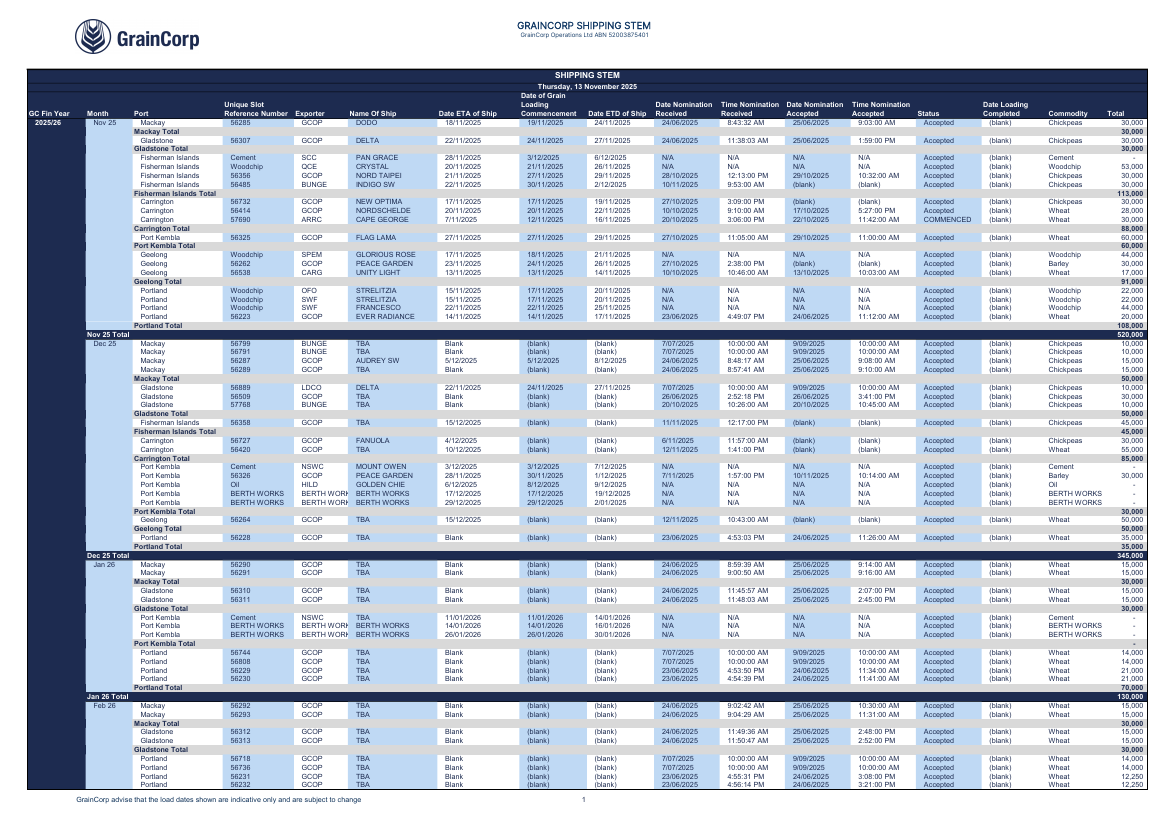

In [ ]:
# Cell 6: Generate thumbnail previews
from pdf2image import convert_from_path
from IPython.display import display, Image as IPImage, HTML
import tempfile
from pathlib import Path

test_images_dir = Path('test_images')
pdf_files = sorted(test_images_dir.glob('*.pdf'))

if pdf_files:
    print("📸 PDF Previews (First Page):\n")
    
    for pdf_path in pdf_files:
        print(f"\n{'='*60}")
        print(f"📄 {pdf_path.name}")
        print(f"{'='*60}")
        
        try:
            # Convert first page to image at low DPI for preview
            images = convert_from_path(str(pdf_path), dpi=100, first_page=1, last_page=1)
            
            if images:
                # Save to temp file and display
                with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp:
                    images[0].save(tmp.name, 'PNG')
                    display(IPImage(filename=tmp.name, width=1200))
                    os.unlink(tmp.name)
        except Exception as e:
            print(f"❌ Failed to generate preview: {e}")
else:
    print("No PDFs found")

## Select PDF to Process

Choose a PDF from the list above to run through the pipeline.

In [ ]:
# Cell 7: Select PDF to process
from pathlib import Path

# Get available PDFs
test_images_dir = Path('test_images')
pdf_files = sorted(test_images_dir.glob('*.pdf'))

if not pdf_files:
    print("❌ No PDFs found in test_images/")
else:
    print("Available PDFs:")
    for i, pdf in enumerate(pdf_files, 1):
        print(f"  {i}. {pdf.name}")
    
    # User selection
    print("\n" + "="*60)
    print("✏️  EDIT THE CELL BELOW TO SELECT A PDF")
    print("="*60)

In [ ]:
from datetime import datetime
# Cell 8: Configure your processing
# ============================================
# EDIT THESE VALUES
# ============================================

# Select PDF file (change this to any PDF in test_images/)
selected_pdf = "graincorp.pdf"  # <-- EDIT THIS

# OCR settings
dpi = 300  # Higher = better quality but slower (300 is good default)
language = 'eng'  # Language code: 'eng', 'jpn', 'chi_sim', etc.

# Output paths
output_dir = Path(f'output_{datetime.now().strftime("%Y%m%d_%H%M%S")}')
output_dir.mkdir(exist_ok=True)

pdf_path = Path('test_images') / selected_pdf
markdown_output = output_dir / f"{pdf_path.stem}_output.md"
json_output = output_dir / f"{pdf_path.stem}_normalized.json"

# Verify file exists
if not pdf_path.exists():
    print(f"❌ File not found: {pdf_path}")
    print(f"\nAvailable files:")
    for f in sorted(Path('test_images').glob('*.pdf')):
        print(f"  - {f.name}")
else:
    print(f"✅ Selected: {pdf_path}")
    print(f"📤 Markdown output: {markdown_output}")
    print(f"📤 JSON output: {json_output}")
    print(f"\nSettings:")
    print(f"  DPI: {dpi}")
    print(f"  Language: {language}")

## Step 1: PDF → Markdown (OCR)

Convert the selected PDF to markdown using Tesseract OCR and spatial table extraction.

In [ ]:
# Cell 9: Run OCR conversion - SEPARATE FILES PER PAGE
import importlib
import pdf_to_markdown
importlib.reload(pdf_to_markdown)
from pdf_to_markdown import pdf_to_markdown_pages
import time

print("🚀 Starting PDF-to-Markdown conversion...\n")
print(f"Input:  {pdf_path}")
print(f"Output: {output_dir}/ (separate file per page)")
print(f"DPI:    {dpi}")
print(f"Lang:   {language}")
print("\n" + "="*60 + "\n")

start_time = time.time()

# Run conversion - creates separate markdown file per page
page_files = pdf_to_markdown_pages(
    pdf_path=str(pdf_path),
    output_dir=str(output_dir),
    dpi=dpi,
    lang=language
)

elapsed = time.time() - start_time

print(f"\n" + "="*60)
print(f"✅ Conversion complete in {elapsed:.1f} seconds")
print(f"📄 Created {len(page_files)} page files:")
for pf in page_files:
    print(f"   - {pf}")
print("="*60)

In [ ]:
# Cell 10: Preview markdown output (first page)
from IPython.display import Markdown, display

print("📄 Markdown Output Preview (Page 1):\n")
print("="*60)

if page_files:
    first_page = page_files[0]
    with open(first_page, 'r', encoding='utf-8') as f:
        page_content = f.read()
    
    # Show stats
    lines = page_content.split('\n')
    
    print(f"File: {first_page}")
    print(f"Characters: {len(page_content):,}")
    print(f"Lines: {len(lines):,}")
    print("\n" + "="*60 + "\n")
    
    # Show first 50 lines
    preview_lines = 50
    preview = '\n'.join(lines[:preview_lines])
    
    print(f"First {preview_lines} lines:\n")
    display(Markdown(preview))
    
    if len(lines) > preview_lines:
        print(f"\n... ({len(lines) - preview_lines} more lines)")
else:
    print("❌ No page files found. Run the conversion cell above first.")

## Step 2: Heal OCR Artifacts

OCR can merge adjacent cells when columns are close together. The healing step fixes this:
1. **Infers** the table structure from OCR output
2. **Detects** merged cells by comparing column counts
3. **Splits** merged values back into proper cells

This is separate from the schema-driven extraction - healing uses an *inferred* schema (what the document shows) while extraction uses your *user* schema (what you want).

In [ ]:
# Cell: Run healing on all pages (parallel phases)
import importlib
import table_healer
importlib.reload(table_healer)
from table_healer import heal_multiple_pages

# Load all page markdown files
pages_content = []
for page_file in page_files:
    with open(page_file, 'r', encoding='utf-8') as f:
        pages_content.append(f.read())

# Run healing pipeline - 3 parallel phases:
#   Phase 1: Infer all schemas in parallel
#   Phase 2: Heal all pages with merged cells in parallel
#   Phase 3: Format all healed pages in parallel
healing_results = await heal_multiple_pages(
    pages_content,
    infer_client="CustomGPT4oMini",
    heal_client="CustomGPT4o",
    format_client="CustomGPT4oMini"
)

# Store healed markdown for later use
healed_pages = [r.healed_markdown for r in healing_results]

In [ ]:
# Cell: Preview healed markdown (first page)
from IPython.display import Markdown, display

print("📄 Healed Markdown Preview (Page 1):\n")
print("="*60)

if healing_results:
    healed_content = healing_results[0].healed_markdown
    lines = healed_content.split('\n')
    
    print(f"Characters: {len(healed_content):,}")
    print(f"Lines: {len(lines):,}")
    
    if healing_results[0].had_merged_cells:
        print(f"Status: HEALED - merged cells were split")
    else:
        print(f"Status: Clean - no merged cells detected")
    
    print("\n" + "="*60 + "\n")
    
    # Show first 30 lines rendered as markdown
    preview_lines = 30
    preview = '\n'.join(lines[:preview_lines])
    
    print(f"First {preview_lines} lines:\n")
    display(Markdown(preview))
    
    if len(lines) > preview_lines:
        print(f"\n... ({len(lines) - preview_lines} more lines)")
else:
    print("❌ No healing results. Run the healing cell above first.")

In [ ]:
# Cell: Save healed markdown files
from pathlib import Path

print("💾 Saving healed markdown files...\n")

healed_page_files = []
for i, result in enumerate(healing_results, 1):
    # Create filename: graincorp_page_1_healed.md
    original_name = Path(page_files[i-1]).stem  # e.g., graincorp_page_1
    healed_filename = f"{original_name}_healed.md"
    healed_path = output_dir / healed_filename
    
    with open(healed_path, 'w', encoding='utf-8') as f:
        f.write(result.healed_markdown)
    
    healed_page_files.append(str(healed_path))
    status = "HEALED" if result.had_merged_cells else "clean"
    print(f"   Page {i}: {healed_path.name} ({status})")

print(f"\n✅ Saved {len(healed_page_files)} healed markdown files to {output_dir}/")

## Step 3: Define Schema for 1NF Conversion

Define the structure you want for the normalized data.

In [ ]:
# Cell 11: Choose or create schema
import json
from pathlib import Path

# Option 1: Use existing example schema
use_example_schema = True  # <-- Set to False to define custom schema below

if use_example_schema:
    schema_path = Path('example_schema.json')
    if schema_path.exists():
        with open(schema_path, 'r') as f:
            user_schema = json.load(f)
        print("📋 Using example schema (example_schema.json)\n")
    else:
        print("❌ example_schema.json not found")
        user_schema = None
else:
    # Option 2: Define custom schema inline
    user_schema = {
        "className": "CustomRecord",
        "fields": {
            "field1": {"type": "string", "description": "First field", "required": True},
            "field2": {"type": "int", "description": "Second field", "required": False},
            # Add more fields as needed
        }
    }
    print("📋 Using custom inline schema\n")

# Display schema
if user_schema:
    print(f"Class Name: {user_schema['className']}")
    print(f"\nFields ({len(user_schema['fields'])}):\n")
    for field_name, field_config in user_schema['fields'].items():
        required = "[REQUIRED]" if field_config.get('required') else "[OPTIONAL]"
        desc = field_config.get('description', 'No description')
        print(f"  • {field_name}: {field_config['type']} {required}")
        print(f"    {desc}")

In [ ]:
# Cell 12: Create your own schema (optional)
# Uncomment and edit this cell to define a completely custom schema

"""
# Example: Invoice Schema
user_schema = {
    "className": "InvoiceLineItem",
    "fields": {
        "item_code": {
            "type": "string",
            "description": "Product or service code",
            "required": True
        },
        "description": {
            "type": "string",
            "description": "Item description",
            "required": False
        },
        "quantity": {
            "type": "int",
            "description": "Quantity ordered",
            "required": False
        },
        "unit_price": {
            "type": "float",
            "description": "Price per unit",
            "required": False
        },
        "total": {
            "type": "float",
            "description": "Line item total",
            "required": False
        }
    }
}

print("✅ Custom schema defined!")
print(f"Class: {user_schema['className']}")
print(f"Fields: {list(user_schema['fields'].keys())}")
"""

## Step 4: Healed Markdown → 1NF (BAML) - Async Parallel Processing

Use BAML to analyze table structure and convert healed markdown to normalized data.
**Async parallel processing - analyze starts immediately, generate follows as soon as analysis completes!**

In [ ]:
# Cell 13: Async parallel analysis and normalization with BAML
# Pipeline: Analyze -> Generate -> Review (validate & complete missing rows)
import asyncio
from table_normalizer_async import (
    process_page_files_async,
    save_parallel_results,
    get_available_clients,
    parse_baml_client_spec
)
from pathlib import Path

# ============================================
# MODEL SELECTION - EDIT THESE TO EXPERIMENT
# ============================================
# Pipeline stages:
#   1. Analyze: Detect table structure (fast model OK)
#   2. Generate: Extract data to 1NF (reliable model)
#   3. Review: Validate & complete any missing rows

analyze_client = "CustomGPT4oMini"  # Fast model for structure analysis
generate_client = "CustomGPT4o"    # Reliable model for data extraction
review_client = "CustomGPT4o"      # Validates and completes missing rows

# Show available clients
print("🤖 Available BAML Clients:")
for client in get_available_clients():
    spec = parse_baml_client_spec(client)
    model = spec.get('options', {}).get('model', 'N/A')
    print(f"   {client}: {model}")

print(f"\n📄 Processing {len(page_files)} separate page files")
print(f"   1. Analyze with: {analyze_client}")
print(f"   2. Generate with: {generate_client}")
print(f"   3. Review with: {review_client}")
print("="*60)

async def run_parallel_processing():
    results = await process_page_files_async(
        page_files=page_files,
        user_schema_json=user_schema,
        analyze_client=analyze_client,
        generate_client=generate_client,
        review_client=review_client
    )
    return results

# Run the async processing
results = await run_parallel_processing()

# Combine all results
all_normalized_data = []
for r in results:
    all_normalized_data.extend(r.normalized_data)

print(f"\n" + "="*60)
print(f"✅ Total records extracted: {len(all_normalized_data)}")

In [ ]:
# Cell 13b: ALTERNATIVE - Streaming results (see pages complete in real-time)
# Uncomment and run this cell INSTEAD of cell 13 to use streaming mode

"""
from table_normalizer_async import process_pages_streaming

print(f"📄 Processing {len(page_files)} page files (streaming mode)\n")
print("="*60)
print("🌊 STREAMING MODE - Results appear as each page completes")
print("="*60 + "\n")

# Read page contents
pages = []
for page_file in page_files:
    with open(page_file, 'r') as f:
        pages.append(f.read())

# Streaming generator - yields results as they complete
streaming_results = []

async def run_streaming():
    async for update in process_pages_streaming(pages, user_schema, pdf_path.name):
        if update["type"] == "schema_ready":
            print(f"📋 Schema ready: {update['schema'].className}")
        elif update["type"] == "page_complete":
            print(f"✅ Page {update['page_number']}: {update['records_count']} records")
            streaming_results.append(update["result"])
        elif update["type"] == "page_error":
            print(f"❌ Page {update['page_number']}: {update['error']}")
        elif update["type"] == "all_complete":
            print(f"\\n🎉 All done: {update['successful_count']}/{update['total_pages']} pages")

await run_streaming()
results = streaming_results
all_normalized_data = []
for r in results:
    all_normalized_data.extend(r.normalized_data)
"""

In [ ]:
# Cell 14: Display analysis results from all pages
from IPython.display import JSON, display

print("📊 Table Structure Analysis (All Pages)\n")
print("="*60 + "\n")

for r in results:
    metadata = r.metadata
    print(f"📄 Page {r.page_number}")
    print(f"   Table Type: {metadata.tableType}")
    print(f"   Orientation: {metadata.dataOrientation}")
    print(f"   Has Headers: {metadata.hasHeaders} | Has Subtotals: {metadata.hasSubtotals}")
    print(f"   Dimensions: ~{metadata.estimatedRows} rows × {metadata.estimatedColumns} cols")
    print(f"   Records: {len(r.normalized_data)}")
    if metadata.notes:
        print(f"   Notes: {metadata.notes}")
    print()

print("="*60)
print(f"\n✅ Total: {len(all_normalized_data)} normalized records across {len(results)} pages")

In [ ]:
# Cell 15: Preview normalized data from all pages
from IPython.display import JSON, display
import json

print("📦 Normalized Data Preview\n")
print("="*60 + "\n")

if all_normalized_data:
    print(f"Total records: {len(all_normalized_data)}\n")
    
    # Show first 5 records
    preview_count = min(5, len(all_normalized_data))
    print(f"First {preview_count} records:\n")
    
    for i, record in enumerate(all_normalized_data[:preview_count], 1):
        print(f"Record {i}:")
        display(JSON(record))
        print()
    
    if len(all_normalized_data) > preview_count:
        print(f"... and {len(all_normalized_data) - preview_count} more records")
else:
    print("⚠️  No records extracted")

In [ ]:
# Cell 16: Save results to JSON (with pipeline config metadata)
from table_normalizer_async import save_parallel_results

print("💾 Saving normalized data...\n")

# Save with client info - this captures the full BAML client spec dynamically
save_parallel_results(
    results, 
    str(json_output),
    analyze_client=analyze_client,
    generate_client=generate_client,
    review_client=review_client
)

# Display file info
file_size = json_output.stat().st_size
print(f"\n📄 File: {json_output}")
print(f"📏 Size: {file_size:,} bytes ({file_size/1024:.1f} KB)")
print(f"\n✨ Output includes pipeline_config with full BAML client specs!")

In [ ]:
# Cell 17: Load and explore saved JSON
import json
from IPython.display import JSON, display

print("📂 Loading saved JSON file...\n")

with open(json_output, 'r', encoding='utf-8') as f:
    saved_data = json.load(f)

# Show pipeline config (new feature!)
if 'pipeline_config' in saved_data:
    print("🔧 Pipeline Configuration:")
    config = saved_data['pipeline_config']
    print(f"   Processed at: {config.get('processed_at', 'N/A')}")
    print(f"\n   Analyze client: {config['analyze_client']['name']}")
    print(f"      Model: {config['analyze_client'].get('options', {}).get('model', 'N/A')}")
    print(f"      Provider: {config['analyze_client'].get('provider', 'N/A')}")
    print(f"\n   Generate client: {config['generate_client']['name']}")
    print(f"      Model: {config['generate_client'].get('options', {}).get('model', 'N/A')}")
    print(f"      Provider: {config['generate_client'].get('provider', 'N/A')}")
    print()

print("Structure:")
print(f"  • total_pages: {saved_data['total_pages']}")
print(f"  • total_records: {saved_data.get('total_records', 'N/A')}")
print(f"  • pages: Array of {len(saved_data['pages'])} page results\n")

total_records = sum(p['record_count'] for p in saved_data['pages'])
print(f"  Verified total records: {total_records}")

print("\n" + "="*60)
print("Complete JSON structure:")
print("="*60)
display(JSON(saved_data, root='Normalized Output'))

## Summary & Next Steps

You've successfully completed the full pipeline!

In [ ]:
# Cell 18: Pipeline summary
print("="*60)
print("✅ PIPELINE COMPLETE!")
print("="*60)

print(f"\n📥 Input:")
print(f"   {pdf_path}")

print(f"\n📤 Outputs:")
print(f"   1. Markdown: {markdown_output}")
print(f"   2. JSON (1NF): {json_output}")

print(f"\n📊 Results:")
print(f"   • Pages processed: {len(results)}")
print(f"   • Total records: {len(all_normalized_data)}")
if results:
    print(f"   • Schema: {results[0].schema.className}")
    print(f"   • Fields: {len(results[0].schema.fields)}")

print(f"\n🚀 Performance:")
print(f"   • Async parallel processing enabled")
print(f"   • All pages analyzed simultaneously")
print(f"   • Generation starts immediately after each page's analysis")

print(f"\n📌 Next Steps:")
print(f"   • Import JSON into your database")
print(f"   • Try different PDFs from test_images/")
print(f"   • Create custom schemas for your use case")

print(f"\n" + "="*60)

In [ ]:
# Cell 19: Batch process all PDFs (optional) - ASYNC VERSION
from pathlib import Path
from pdf_to_markdown import pdf_to_markdown
from table_normalizer_async import (
    process_ocr_markdown_async,
    save_parallel_results
)
import time
import asyncio

# Set to True to run batch processing
run_batch = False  # <-- Change to True to process all PDFs

if run_batch:
    test_images_dir = Path('test_images')
    pdf_files = sorted(test_images_dir.glob('*.pdf'))
    output_dir = Path('output')
    output_dir.mkdir(exist_ok=True)
    
    print(f"🚀 Batch processing {len(pdf_files)} PDF files (async parallel)...\n")
    print("="*60 + "\n")
    
    results_summary = []
    
    async def process_all_pdfs():
        for i, pdf_path in enumerate(pdf_files, 1):
            print(f"[{i}/{len(pdf_files)}] Processing: {pdf_path.name}")
            
            md_output = output_dir / f"{pdf_path.stem}.md"
            json_output = output_dir / f"{pdf_path.stem}_normalized.json"
            
            start = time.time()
            
            try:
                # Step 1: PDF to Markdown (still sync - CPU/OCR bound)
                pdf_to_markdown(str(pdf_path), str(md_output), dpi=300, lang='eng')
                
                # Step 2: Async parallel normalization
                page_results = await process_ocr_markdown_async(
                    str(md_output),
                    user_schema_json=user_schema
                )
                
                # Step 3: Save
                save_parallel_results(page_results, str(json_output))
                
                elapsed = time.time() - start
                total_records = sum(len(r.normalized_data) for r in page_results)
                
                results_summary.append({
                    'file': pdf_path.name,
                    'status': 'success',
                    'pages': len(page_results),
                    'records': total_records,
                    'time': elapsed
                })
                
                print(f"   ✅ {len(page_results)} pages, {total_records} records in {elapsed:.1f}s")
                
            except Exception as e:
                results_summary.append({
                    'file': pdf_path.name,
                    'status': 'failed',
                    'error': str(e)
                })
                print(f"   ❌ Failed: {e}")
            
            print()
        
        return results_summary
    
    results_summary = await process_all_pdfs()
    
    # Summary
    print("\n" + "="*60)
    print("BATCH PROCESSING SUMMARY")
    print("="*60 + "\n")
    
    successful = [r for r in results_summary if r['status'] == 'success']
    failed = [r for r in results_summary if r['status'] == 'failed']
    
    print(f"✅ Successful: {len(successful)}")
    print(f"❌ Failed: {len(failed)}")
    
    if successful:
        total_records = sum(r['records'] for r in successful)
        total_pages = sum(r['pages'] for r in successful)
        avg_time = sum(r['time'] for r in successful) / len(successful)
        print(f"\nTotal pages processed: {total_pages}")
        print(f"Total records extracted: {total_records}")
        print(f"Average processing time: {avg_time:.1f}s per PDF")
    
    from IPython.display import JSON
    display(JSON(results_summary))
else:
    print("ℹ️  Batch processing disabled")
    print("   Set run_batch = True to process all PDFs")

In [ ]:
# Cell 19: Batch process all PDFs (optional)
from pathlib import Path
from pdf_to_markdown import pdf_to_markdown
from table_normalizer import process_ocr_table, save_normalized_data
import time

# Set to True to run batch processing
run_batch = False  # <-- Change to True to process all PDFs

if run_batch:
    test_images_dir = Path('test_images')
    pdf_files = sorted(test_images_dir.glob('*.pdf'))
    output_dir = Path('output')
    output_dir.mkdir(exist_ok=True)
    
    print(f"🚀 Batch processing {len(pdf_files)} PDF files...\n")
    print("="*60 + "\n")
    
    results_summary = []
    
    for i, pdf_path in enumerate(pdf_files, 1):
        print(f"[{i}/{len(pdf_files)}] Processing: {pdf_path.name}")
        
        md_output = output_dir / f"{pdf_path.stem}.md"
        json_output = output_dir / f"{pdf_path.stem}_normalized.json"
        
        start = time.time()
        
        try:
            # Step 1: PDF to Markdown
            pdf_to_markdown(str(pdf_path), str(md_output), dpi=300, lang='eng')
            
            # Step 2: Read markdown
            with open(md_output, 'r', encoding='utf-8') as f:
                md_content = f.read()
            
            # Step 3: Normalize to 1NF
            result = process_ocr_table(
                markdown_content=md_content,
                page_context=f"{pdf_path.name}",
                user_schema_json=user_schema
            )
            
            # Step 4: Save
            save_normalized_data(result, str(json_output))
            
            elapsed = time.time() - start
            
            results_summary.append({
                'file': pdf_path.name,
                'status': 'success',
                'records': len(result.normalized_data),
                'table_type': result.metadata.tableType,
                'time': elapsed
            })
            
            print(f"   ✅ {len(result.normalized_data)} records in {elapsed:.1f}s")
            
        except Exception as e:
            results_summary.append({
                'file': pdf_path.name,
                'status': 'failed',
                'error': str(e)
            })
            print(f"   ❌ Failed: {e}")
        
        print()
    
    # Summary
    print("\n" + "="*60)
    print("BATCH PROCESSING SUMMARY")
    print("="*60 + "\n")
    
    successful = [r for r in results_summary if r['status'] == 'success']
    failed = [r for r in results_summary if r['status'] == 'failed']
    
    print(f"✅ Successful: {len(successful)}")
    print(f"❌ Failed: {len(failed)}")
    
    if successful:
        total_records = sum(r['records'] for r in successful)
        avg_time = sum(r['time'] for r in successful) / len(successful)
        print(f"\nTotal records extracted: {total_records}")
        print(f"Average processing time: {avg_time:.1f}s per PDF")
    
    display(JSON(results_summary))
else:
    print("ℹ️  Batch processing disabled")
    print("   Set run_batch = True to process all PDFs")